# Belajar Alur Lapisan 2 — Langkah demi Langkah

> **Ini alat belajar, bukan bagian produk.**
> Notebook ini tidak melatih apa pun, tidak menghasilkan angka untuk lomba, dan tidak menyentuh
> skrip yang sudah ada. Ia cuma **memanggil** kode yang sudah jalan (`dataset.py`,
> `models_real.py`, `stgnn_final.pt`) supaya kamu bisa melihat datanya berubah bentuk di tiap
> langkah.
>
> Untuk versi yang lengkap dan formal, lihat `checkpoint_walkthrough.ipynb`.

### Yang akan kamu lihat

Angka pohon menyusut di sepanjang alur, dan tiap penyusutan ada alasannya:

```
1.200 pohon  (seluruh kebun di Eg9PP)
    │
    ├─ 528 keluar  →  sudah bergejala / mati / tersensor
    ▼
  672 pohon  (risk set — masih sehat, jadi masih bisa diramal)
    ▼
  672 skor risiko
```

### Enam langkah

| | Langkah | Yang dicetak |
|---|---|---|
| 1 | Muat CSV | bentuk tabel |
| 2 | Bangun graf | jumlah sisi + derajat |
| 3 | Tunjukkan risk set | 672 vs 528 |
| 4 | Muat checkpoint | isi berkas model |
| 5 | Beri skor | 10 pohon paling berisiko |
| 6 | Gambar peta risiko | peta kebun |

---

> ⚠️ **Kalau sel pertama error `No module named 'numpy'`**
> Kernel-nya salah. Pilih **`Python 3.11 (SawitGuard)`** lewat pemilih kernel di kanan atas
> (VS Code) atau menu *Kernel → Change Kernel* (JupyterLab).

## Persiapan

Kita cuma butuh dua modul dari repo: `dataset.py` (semua soal data) dan `models_real.py`
(arsitektur model). Keduanya sudah ada — kita tidak menulis ulang apa pun.

In [1]:
import os, sys
import numpy as np
import torch

# Cari folder layer2_real, apa pun posisi notebook-nya.
HERE = os.path.abspath("." if os.path.basename(os.getcwd()) == "layer2_real"
                       else os.path.join(".", "layer2_real"))
assert os.path.exists(os.path.join(HERE, "dataset.py")), f"folder salah: {HERE}"
if HERE not in sys.path:
    sys.path.insert(0, HERE)

import dataset as ds        # semua urusan data: CSV -> tensor, graf, risk set
import models_real as M     # arsitektur STGNN

print("interpreter :", sys.executable)     # harus C:\Program Files\Python311\python.exe
print("folder      :", HERE)
print()
print("Aturan main yang dipakai di sepanjang alur:")
print(f"  WINDOW   = {ds.WINDOW}  -> model membaca {ds.WINDOW} sensus riwayat")
print(f"  HORIZONS = {ds.HORIZONS}  -> seberapa jauh ke depan diramal (satuan SENSUS)")
print(f"  N_REL    = {ds.N_REL}  -> cuma satu jenis hubungan antar-pohon: kedekatan")

interpreter : c:\Program Files\Python311\python.exe
folder      : c:\Users\Rifqi\Documents\Datathon\oil-palm-detection-datathon-2026\layer2_real

Aturan main yang dipakai di sepanjang alur:
  WINDOW   = 3  -> model membaca 3 sensus riwayat
  HORIZONS = (1, 2, 3, 4)  -> seberapa jauh ke depan diramal (satuan SENSUS)
  N_REL    = 1  -> cuma satu jenis hubungan antar-pohon: kedekatan


## Langkah 1 — Muat CSV dan lihat bentuknya

`dataset.py` **tidak pernah** membaca `Eg9PP_Phenotypes.csv` yang mentah. Yang dibaca adalah tiga
CSV yang sudah "dibekukan" lebih dulu oleh `data_clean/build_layer2_real.py`.

Kenapa dibekukan? Supaya angkanya tidak berubah diam-diam. Skrip pembeku itu punya pemeriksaan
otomatis yang **menghentikan proses** kalau jumlah sensus, jumlah sisi, atau bentuk kisinya
bergeser.

Tiga CSV itu isinya:

| Berkas | Isi | Bentuk |
|---|---|---|
| `layer2_nodes.csv` | satu baris = satu pohon | 1.200 baris |
| `layer2_panel.csv` | satu baris = satu pohon pada satu sensus | 1.200 × 45 = 54.000 baris |
| `layer2_edges.csv` | satu baris = satu sisi graf | 3.354 baris |

In [2]:
# Muat ketiga CSV sekaligus.
nodes, panel, edges = ds.load()

print("BENTUK TABEL")
print(f"  nodes : {nodes.shape[0]:>6} baris x {nodes.shape[1]:>2} kolom  -> daftar pohon")
print(f"  panel : {panel.shape[0]:>6} baris x {panel.shape[1]:>2} kolom  -> pohon x sensus")
print(f"  edges : {edges.shape[0]:>6} baris x {edges.shape[1]:>2} kolom  -> daftar sisi graf")

# Berapa sensus dan berapa pohon?
cen = ds.census()        # tanggal tiap sensus, dalam tahun
T, N = ds.shape()        # T = jumlah sensus, N = jumlah pohon

print()
print("UKURAN DASAR")
print(f"  N (pohon)  = {N}")
print(f"  T (sensus) = {T}, dari tahun {cen.min():.1f} sampai {cen.max():.1f}")
print(f"  cek: {N} pohon x {T} sensus = {N*T} baris panel (cocok: {N*T == panel.shape[0]})")

print()
print("Kolom nodes:", list(nodes.columns))
nodes.head(3)

BENTUK TABEL
  nodes :   1200 baris x 13 kolom  -> daftar pohon
  panel :  54000 baris x  9 kolom  -> pohon x sensus
  edges :   3354 baris x  3 kolom  -> daftar sisi graf

UKURAN DASAR
  N (pohon)  = 1200
  T (sensus) = 45, dari tahun 0.5 sampai 25.5
  cek: 1200 pohon x 45 sensus = 54000 baris panel (cocok: True)

Kolom nodes: ['palm_id', 'progeny', 'ga_parent', 'gb_parent', 'parcel', 'plot', 'xm', 'ym', 'event_t1s', 'y_t1s', 'event_td', 'y_td', 'fold']


,palm_id,progeny,ga_parent,gb_parent,parcel,plot,xm,ym,event_t1s,y_t1s,event_td,y_td,fold
0,D1L3_1,D1L3,D1,L3,44A,68,7.794229,3.5,1,25.5,0,25.5,44A
1,D1L3_2,D1L3,D1,L3,44A,68,7.794229,4.5,1,7.5,1,8.5,44A
2,D1L3_3,D1L3,D1,L3,44A,68,7.794229,5.5,1,8.0,1,8.5,44A


In [3]:
# Sensus TIDAK berjarak sama. Ada yang selang 0,5 tahun, ada yang 1,0 tahun.
jarak = sorted(set(np.round(np.diff(cen), 3)))
print("Jarak antar-sensus yang muncul:", jarak, "tahun")
print()
print("-> Karena tidak teratur, horizon 'h' dihitung dalam LANGKAH SENSUS, bukan tahun.")
print("   h=3 berarti 'tiga sensus berikutnya', yang panjangnya bisa 1,5 sampai 3 tahun.")

print()
print("Contoh: 8 sensus pertama ada di tahun", [f"{t:.1f}" for t in cen[:8]])

Jarak antar-sensus yang muncul: [0.5, 1.0] tahun

-> Karena tidak teratur, horizon 'h' dihitung dalam LANGKAH SENSUS, bukan tahun.
   h=3 berarti 'tiga sensus berikutnya', yang panjangnya bisa 1,5 sampai 3 tahun.

Contoh: 8 sensus pertama ada di tahun ['0.5', '1.5', '2.5', '3.5', '4.0', '4.5', '5.0', '6.0']


## Langkah 2 — Bangun graf: berapa sisi, berapa derajat

Graf ini sederhana: **dua pohon dihubungkan kalau jaraknya ≤ 1,5 × jarak tanam.**

Sawit ditanam dalam pola segitiga sama sisi, jadi tiap pohon di bagian dalam punya **6 tetangga
langsung**. Radius 1,5 pas hanya menjangkau keenam tetangga itu — tidak lebih.

Dua angka yang wajib cocok:

- **3.354 sisi**
- **derajat rata-rata 5,59** (bukan tepat 6, karena pohon di pinggir kebun punya tetangga lebih sedikit)

Kalau derajatnya keluar ≈ 8, berarti koreksi koordinat gagal dan kisinya terbaca sebagai persegi.

In [4]:
# Ambil matriks ketetanggaan (adjacency). Ukurannya 1200 x 1200.
# Isinya 1 kalau dua pohon bertetangga, 0 kalau tidak.
A = np.asarray(ds.adjacency("true"), np.float32)

derajat = A.sum(1)          # jumlah tetangga tiap pohon
n_sisi = int(A.sum() // 2)  # dibagi 2 karena tiap sisi terhitung dua kali

print("GRAF KEDEKATAN")
print(f"  bentuk matriks   : {A.shape}")
print(f"  jumlah sisi      : {n_sisi}      <- harapan 3354")
print(f"  derajat rata-rata: {derajat.mean():.2f}    <- harapan 5.59")
print(f"  derajat terkecil : {int(derajat.min())} (pohon di pojok kebun)")
print(f"  derajat terbesar : {int(derajat.max())} (pohon di tengah, dikelilingi 6 tetangga)")

print()
print("Sebaran derajat (berapa pohon punya berapa tetangga):")
for d in range(int(derajat.max()) + 1):
    jml = int((derajat == d).sum())
    if jml:
        print(f"  {d} tetangga : {jml:>4} pohon  {'#' * (jml // 15)}")

GRAF KEDEKATAN
  bentuk matriks   : (1200, 1200)
  jumlah sisi      : 3354      <- harapan 3354
  derajat rata-rata: 5.59    <- harapan 5.59
  derajat terkecil : 2 (pohon di pojok kebun)
  derajat terbesar : 6 (pohon di tengah, dikelilingi 6 tetangga)

Sebaran derajat (berapa pohon punya berapa tetangga):
  2 tetangga :    4 pohon  
  3 tetangga :  100 pohon  ######
  4 tetangga :   40 pohon  ##
  5 tetangga :   96 pohon  ######
  6 tetangga :  960 pohon  ################################################################


In [5]:
# Kenapa membelah data per parcel itu boleh? Karena tidak ada satu pun sisi
# yang menyeberang antar-parcel. Memisahkan parcel tidak memutus graf.
parcel_pohon = nodes.set_index("palm_id").parcel
sisi_nyebrang = int((parcel_pohon[edges.a].to_numpy()
                     != parcel_pohon[edges.b].to_numpy()).sum())

print("PEMERIKSAAN PENTING")
print(f"  sisi yang menyeberang antar-parcel: {sisi_nyebrang} dari {n_sisi}")
print("  -> 0 artinya kedua parcel benar-benar terpisah secara spasial,")
print("     jadi melatih di satu parcel dan menguji di parcel lain itu SAH.")

print()
print("Isi tiap parcel:")
for p, grup in nodes.groupby("parcel"):
    print(f"  {p}: {len(grup):>4} pohon")

PEMERIKSAAN PENTING
  sisi yang menyeberang antar-parcel: 0 dari 3354
  -> 0 artinya kedua parcel benar-benar terpisah secara spasial,
     jadi melatih di satu parcel dan menguji di parcel lain itu SAH.

Isi tiap parcel:
  44A:  720 pohon
  44B:  480 pohon


## Langkah 3 — Risk set: 672 masih bisa diramal, 528 tidak

Ini bagian yang paling penting untuk dipahami.

Model ini menjawab pertanyaan: **"pohon yang SEKARANG masih sehat, apakah akan sakit dalam 3
sensus ke depan?"**

Artinya pohon yang **sudah** sakit atau mati tidak ikut diramal — nasibnya sudah ketahuan. Pohon
seperti itu **keluar dari risk set**.

Ada empat status:

| Status | Arti | Ikut diramal? |
|---|---|---|
| `A` | asimptomatik (masih sehat) | ✅ ya |
| `S` | sudah bergejala | ❌ tidak |
| `D` | mati | ❌ tidak |
| `C` | tersensor (keluar dari pengamatan) | ❌ tidak |

**`C` bukan berarti sehat.** Pohon tersensor itu nasibnya *tidak diketahui* — mungkin sakit,
mungkin tidak, kita kehilangan jejaknya. Menghitungnya sebagai "sehat" akan membuat model
kelihatan lebih pintar daripada yang sebenarnya. Jadi ia dikeluarkan, bukan dijadikan negatif.

In [5]:
# Matriks status: baris = sensus, kolom = pohon. Isinya huruf A/S/D/C.
st = ds.status_matrix()
print(f"matriks status: {st.shape}  (45 sensus x 1200 pohon)")

# Kita pakai sensus TERAKHIR yang masih sah untuk h=3.
# Kenapa terakhir? Karena itu yang paling mutakhir - paling mirip situasi nyata.
h = 3
t_star = T - 1 - h        # 45 - 1 - 3 = 41
print(f"\nsensus yang dipakai: indeks {t_star} (tahun {cen[t_star]:.1f})")
print(f"  kenapa {t_star}? butuh {h} sensus ke depan untuk tahu jawabannya,")
print(f"  jadi sensus paling akhir yang bisa dipakai adalah {T}-1-{h} = {t_star}.")

import collections
hitung = collections.Counter(st[t_star])
print(f"\nSTATUS SEMUA POHON DI SENSUS {t_star}:")
arti = {"A": "masih sehat  -> IKUT diramal",
        "S": "sudah bergejala", "D": "mati", "C": "tersensor (nasib tak diketahui)"}
for s in "ASDC":
    print(f"  {s} : {hitung.get(s,0):>4} pohon   {arti[s]}")
print(f"  {'':>5}{'-'*4}")
print(f"      {sum(hitung.values()):>4} pohon total")

matriks status: (45, 1200)  (45 sensus x 1200 pohon)

sensus yang dipakai: indeks 41 (tahun 24.0)
  kenapa 41? butuh 3 sensus ke depan untuk tahu jawabannya,
  jadi sensus paling akhir yang bisa dipakai adalah 45-1-3 = 41.

STATUS SEMUA POHON DI SENSUS 41:
  A :  672 pohon   masih sehat  -> IKUT diramal
  S :  191 pohon   sudah bergejala
  D :  296 pohon   mati
  C :   41 pohon   tersensor (nasib tak diketahui)
       ----
      1200 pohon total


In [6]:
# Sekarang panggil fungsi yang benar-benar membentuk contoh untuk model.
# Ia mengembalikan: pohon mana, sensus mana, dan jawabannya (0/1).
tree, t_idx, y = ds.build_examples(h, np.array([t_star]))

luar = N - len(tree)
print("PENYUSUTAN DATA")
print(f"  mulai dari          : {N} pohon (seluruh kebun)")
print(f"  keluar dari risk set: {luar} pohon (status S / D / C)")
print(f"  {'':>22}{'-'*4}")
print(f"  sisa untuk diramal  : {len(tree)} pohon   <-- INI RISK SET")
print()
print(f"  {100*len(tree)/N:.1f}% kebun masih bisa diramal di tahun {cen[t_star]:.1f}")

print("\nJAWABAN SEBENARNYA (buat pembanding, model tidak melihat ini):")
print(f"  akan sakit dalam {h} sensus : {int(y.sum())} pohon ({100*y.mean():.2f}%)")
print(f"  tetap sehat                : {int((y==0).sum())} pohon")

# PENTING: bandingkan dengan rata-rata seluruh sensus, karena angkanya jauh beda.
_, _, y_semua = ds.build_examples(h, np.arange(T))
print(f"\nBANDINGKAN DENGAN RATA-RATA SELURUH {T} SENSUS: {100*y_semua.mean():.2f}% positif")
print(f"  Di sensus {t_star} angkanya jauh lebih tinggi ({100*y.mean():.1f}%). Kenapa?")
print(f"  Karena ini sudah tahun ke-{cen[t_star]:.0f}: wabahnya sudah lanjut, dan pohon")
print(f"  yang masih sehat pun sekarang dikelilingi banyak tetangga yang sakit.")
print(f"  Jadi risk set bukan cuma MENGECIL ({N} -> {len(tree)}), tapi juga makin BERISIKO.")
print(f"\n-> Model dilatih di rata-rata {100*y_semua.mean():.2f}% positif. Di angka serendah itu,")
print(f"   AKURASI tidak berguna: model yang selalu jawab 'sehat' langsung dapat")
print(f"   {100*(1-y_semua.mean()):.0f}% akurasi tanpa menolong siapa pun. Karena itu metriknya AUC-PR.")

PENYUSUTAN DATA
  mulai dari          : 1200 pohon (seluruh kebun)
  keluar dari risk set: 528 pohon (status S / D / C)
                        ----
  sisa untuk diramal  : 672 pohon   <-- INI RISK SET

  56.0% kebun masih bisa diramal di tahun 24.0

JAWABAN SEBENARNYA (buat pembanding, model tidak melihat ini):
  akan sakit dalam 3 sensus : 214 pohon (31.85%)
  tetap sehat                : 458 pohon

BANDINGKAN DENGAN RATA-RATA SELURUH 45 SENSUS: 4.69% positif
  Di sensus 41 angkanya jauh lebih tinggi (31.8%). Kenapa?
  Karena ini sudah tahun ke-24: wabahnya sudah lanjut, dan pohon
  yang masih sehat pun sekarang dikelilingi banyak tetangga yang sakit.
  Jadi risk set bukan cuma MENGECIL (1200 -> 672), tapi juga makin BERISIKO.

-> Model dilatih di rata-rata 4.69% positif. Di angka serendah itu,
   AKURASI tidak berguna: model yang selalu jawab 'sehat' langsung dapat
   95% akurasi tanpa menolong siapa pun. Karena itu metriknya AUC-PR.


## Langkah 4 — Muat checkpoint dan lihat isinya

`stgnn_final.pt` bukan cuma tumpukan angka bobot. Ia juga membawa **keterangan** tentang dirinya
sendiri, supaya orang yang membukanya enam bulan lagi tahu model ini dilatih untuk apa.

Dua isi yang paling penting:

- **`palm_ids`** — urutan pohon. Tanpa ini, nomor baris di tensor tidak ada artinya, dan skor bisa
  menempel ke pohon yang salah tanpa error apa pun.
- **`scope_warning`** — peringatan bahwa model ini dilatih tanpa data uji, jadi **angka
  kinerjanya tidak boleh dikutip**.

In [ ]:
CKPT = os.path.join(HERE, "stgnn_final.pt")
assert os.path.exists(CKPT), "stgnn_final.pt belum ada. Jalankan: python train_final.py"

try:
    ck = torch.load(CKPT, map_location="cpu", weights_only=True)
except Exception:
    ck = torch.load(CKPT, map_location="cpu", weights_only=False)

print(f"berkas: stgnn_final.pt ({os.path.getsize(CKPT)/1024:.1f} KB)\n")
print("ISI CHECKPOINT:")
for k, v in ck.items():
    if k == "state_dict":
        print(f"  {k:<16} -> {len(v)} tensor bobot (ini modelnya)")
    elif isinstance(v, dict):
        print(f"  {k:<16} -> keterangan ({len(v)} isian)")
    elif isinstance(v, str):
        print(f"  {k:<16} -> tulisan ({len(v)} huruf)")
    else:
        print(f"  {k:<16} -> {v}")

print("\nMODEL INI DILATIH UNTUK APA:")
print(f"  horizon      : {ck['task']['horizon']} sensus ke depan")
print(f"  jendela      : {ck['task']['window']} sensus riwayat")
print(f"  dilatih pada : {ck['train']['n_examples']} contoh")
print(f"  positif      : {ck['train']['n_positives']} ({100*ck['train']['pos_rate']:.2f}%)")
print(f"  lipatan      : {ck['train']['fold']}")
print(f"  jumlah bobot : {ck['train']['n_params']}")

berkas: stgnn_final.pt (60.4 KB)

ISI CHECKPOINT:
  format_version   -> 1
  scope_warning    -> tulisan (378 huruf)
  model_class      -> tulisan (5 huruf)
  arch             -> keterangan (3 isian)
  state_dict       -> 10 tensor bobot (ini modelnya)
  task             -> keterangan (5 isian)
  train            -> keterangan (14 isian)
  data             -> keterangan (11 isian)
  probe            -> keterangan (5 isian)

MODEL INI DILATIH UNTUK APA:
  horizon      : 3 sensus ke depan
  jendela      : 3 sensus riwayat
  dilatih pada : 40828 contoh
  positif      : 1915 (4.69%)
  lipatan      : NONE -- all 1,200 palms, both parcels
  jumlah bobot : 8875


: 

In [9]:
# Bobot modelnya sendiri - ternyata kecil sekali.
print("BOBOT MODEL (state_dict):")
for k, v in ck["state_dict"].items():
    print(f"  {k:<16} {str(tuple(v.shape)):<12} {v.numel():>5} angka")
print(f"  {'TOTAL':<16} {'':<12} {sum(v.numel() for v in ck['state_dict'].values()):>5} angka")
print("\n-> ~8.900 angka. Model ini memang sengaja kecil: datanya cuma 1.200 pohon,")
print("   model besar akan langsung menghafal.")

print("\n" + "="*70)
print("PERINGATAN YANG IKUT TERSIMPAN DI DALAM BERKAS:")
print("="*70)
print(ck["scope_warning"])

BOBOT MODEL (state_dict):
  w_self.weight    (34, 24)       816 angka
  w_self.bias      (34,)           34 angka
  w_agg.weight     (34, 24)       816 angka
  w_agg.bias       (34,)           34 angka
  gru.weight_ih    (102, 34)     3468 angka
  gru.weight_hh    (102, 34)     3468 angka
  gru.bias_ih      (102,)         102 angka
  gru.bias_hh      (102,)         102 angka
  readout.weight   (1, 34)         34 angka
  readout.bias     (1,)             1 angka
  TOTAL                          8875 angka

-> ~8.900 angka. Model ini memang sengaja kecil: datanya cuma 1.200 pohon,
   model besar akan langsung menghafal.

PERINGATAN YANG IKUT TERSIMPAN DI DALAM BERKAS:
Trained on ALL 1,200 palms with no held-out set. This is an INFERENCE artifact, not an evaluation artifact. No performance number may be quoted from this model; performance numbers come only from run_real.py / run_v2.py (leave-one-parcel-out). Its output is a RELATIVE score for ranking, not a calibrated probability -- never

## Langkah 5 — Beri skor, lihat 10 pohon paling berisiko

Sekarang alurnya lengkap. Perhatikan bentuk tensornya berubah di tiap baris — dari seluruh kebun
(1.200) menyusut jadi risk set (672).

Yang perlu dipahami: **model melihat dua hal**.

- `F_seq` — riwayat pohon **itu sendiri**. Bagian statusnya selalu nol, karena pohon di risk set
  pasti sehat. Jadi praktis isinya cuma waktu + genotipe.
- `D_seq` — riwayat **tetangganya**, hasil `A @ F`. Di sinilah sinyal penyakitnya berada.

Jadi model sebenarnya menebak dari **kondisi tetangga**, bukan dari kondisi pohon itu sendiri.

In [10]:
# --- Siapkan bahan masukan model ---
F = np.asarray(ds.node_features(np.arange(T)), np.float32)   # fitur tiap pohon tiap sensus
D = ds.diffuse(F, A)                                          # sebar ke tetangga: D = A @ F

print("BENTUK TENSOR")
print(f"  F (fitur)        : {F.shape}   <- (sensus, pohon, fitur)")
print(f"  A (graf)         : {A.shape}")
print(f"  D (dari tetangga): {D.shape}  <- hasil A @ F")

# --- Ambil hanya jendela 3 sensus untuk pohon di risk set ---
F_seq, D_seq = ds.make_windows(tree, t_idx, F, D)
print(f"\nSetelah disaring ke risk set + jendela {ds.WINDOW} sensus:")
print(f"  F_seq : {F_seq.shape}   <- {len(tree)} pohon, {ds.WINDOW} sensus, {F.shape[2]} fitur")
print(f"  D_seq : {D_seq.shape}")
print(f"\n  Perhatikan: 1200 -> {len(tree)}. Yang 528 tidak ikut ke sini.")

BENTUK TENSOR
  F (fitur)        : (45, 1200, 24)   <- (sensus, pohon, fitur)
  A (graf)         : (1200, 1200)
  D (dari tetangga): (45, 1200, 1, 24)  <- hasil A @ F

Setelah disaring ke risk set + jendela 3 sensus:
  F_seq : (672, 3, 24)   <- 672 pohon, 3 sensus, 24 fitur
  D_seq : (672, 3, 1, 24)

  Perhatikan: 1200 -> 672. Yang 528 tidak ikut ke sini.


In [11]:
# --- Bangun ulang model dari checkpoint, lalu beri skor ---
model = M.build(ck["model_class"], ck["arch"]["in_dim"], horizon=h)
model.load_state_dict(ck["state_dict"], strict=True)
model.eval()   # mode inferensi, bukan latih

with torch.no_grad():                     # tidak perlu hitung gradien, cuma meramal
    skor = model(torch.as_tensor(F_seq), torch.as_tensor(D_seq)).numpy()

print("HASIL")
print(f"  skor keluar : {skor.shape}  <- satu angka untuk tiap pohon di risk set")
print(f"  rentang     : {skor.min():+.4f} sampai {skor.max():+.4f}")
print()
print("  Angka ini BUKAN persentase dan BUKAN peluang.")
print("  Gunanya hanya untuk MENGURUTKAN: makin besar = makin berisiko.")

HASIL
  skor keluar : (672,)  <- satu angka untuk tiap pohon di risk set
  rentang     : -0.5594 sampai +0.5140

  Angka ini BUKAN persentase dan BUKAN peluang.
  Gunanya hanya untuk MENGURUTKAN: makin besar = makin berisiko.


In [12]:
# --- 10 pohon paling berisiko ---
ids = np.asarray(ck["data"]["palm_ids"])          # nama pohon, urutannya dari checkpoint
tetangga_sakit = (A @ np.isin(st[t_star], ("S", "D")).astype(float)).astype(int)

urut = np.argsort(-skor)[:10]                      # urutkan dari skor terbesar

print("10 POHON PALING BERISIKO")
print(f"(diramal untuk {h} sensus setelah tahun {cen[t_star]:.1f})\n")
print(f"{'#':>3} {'nama pohon':>11} {'parcel':>7} {'skor':>9} {'tetangga sakit':>16}")
print("-" * 52)
for peringkat, k in enumerate(urut, 1):
    i = tree[k]
    print(f"{peringkat:>3} {ids[i]:>11} {nodes.parcel.iloc[i]:>7} {skor[k]:>+9.4f} "
          f"{tetangga_sakit[i]:>13}/{int(derajat[i])}")

# Bandingkan dengan yang paling aman, biar kelihatan polanya.
paling_aman = np.argsort(skor)[:10]
print(f"\nRATA-RATA TETANGGA SAKIT:")
print(f"  10 paling berisiko : {tetangga_sakit[tree[urut]].mean():.2f} tetangga sakit")
print(f"  seluruh risk set   : {tetangga_sakit[tree].mean():.2f}")
print(f"  10 paling aman     : {tetangga_sakit[tree[paling_aman]].mean():.2f}")
print("\n-> Modelnya memang membaca kondisi tetangga. Masuk akal secara biologi:")
print("   Ganoderma menular lewat kontak akar antar-pohon yang berdekatan.")

10 POHON PALING BERISIKO
(diramal untuk 3 sensus setelah tahun 24.0)

  #  nama pohon  parcel      skor   tetangga sakit
----------------------------------------------------
  1     D2L3_54     44B   +0.5140             4/6
  2     D2L3_55     44B   +0.5111             4/6
  3      D2L3_6     44A   +0.5087             5/6
  4     D2L3_51     44B   +0.4796             5/6
  5     D2L3_71     44B   +0.4718             4/6
  6     D2L3_26     44A   +0.4162             4/6
  7     D2L3_60     44B   +0.3832             3/6
  8     D5L2_20     44A   +0.3782             4/6
  9     D2L3_46     44B   +0.3769             4/6
 10      D2L3_9     44A   +0.3703             3/6

RATA-RATA TETANGGA SAKIT:
  10 paling berisiko : 4.00 tetangga sakit
  seluruh risk set   : 1.97
  10 paling aman     : 0.40

-> Modelnya memang membaca kondisi tetangga. Masuk akal secara biologi:
   Ganoderma menular lewat kontak akar antar-pohon yang berdekatan.


## Langkah 6 — Gambar peta risikonya

Terakhir, kita taruh skornya di atas denah kebun.

Dua hal yang sengaja dipilih:

- **Warna pakai peringkat (desil), bukan skor mentah.** Karena skornya tidak terkalibrasi, jarak
  antar-angka tidak berarti apa-apa — yang berarti cuma urutannya. Warna bertingkat 1–10 memaksa
  pembaca membaca urutan, bukan selisih.
- **Pohon di luar risk set diwarnai abu-abu**, bukan dihilangkan. Kalau dihilangkan, petanya akan
  terlihat seperti kebun yang jarang, padahal 528 pohon itu ada — hanya saja sudah sakit.

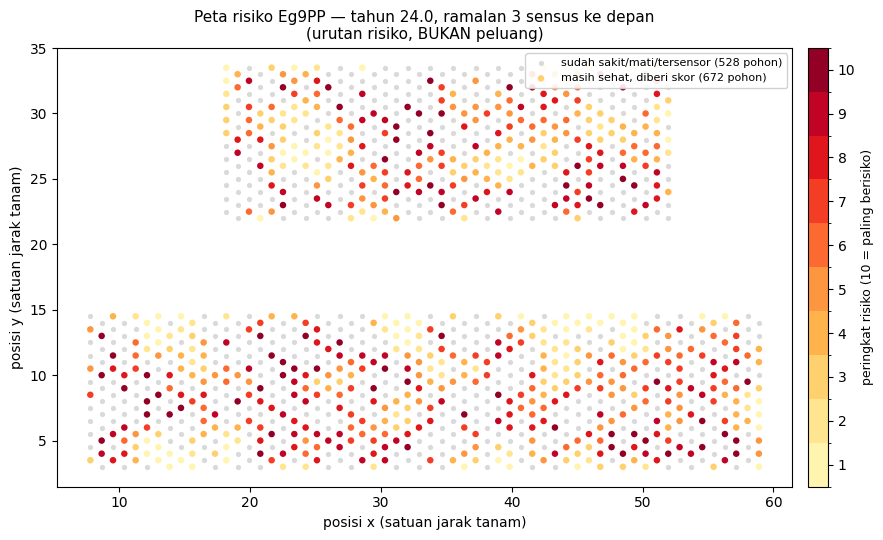

Yang bisa dibaca dari peta ini:
  1. Dua kotak terpisah = dua parcel (44A bawah, 44B atas).
     Jaraknya jauh, jadi tidak ada sisi graf yang menyeberang.
  2. Titik abu-abu tersebar merata = penyakitnya sudah menyebar ke mana-mana
     setelah 24 tahun (528 dari 1200 pohon).
  3. Warna merah tua cenderung berkelompok, tidak acak =
     pohon berisiko tinggi berdekatan dengan pohon yang sudah sakit.


In [13]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap

# Ubah skor jadi desil 1-10 (10 = paling berisiko)
posisi = np.argsort(np.argsort(-skor))                  # 0 = paling berisiko
desil = 10 - np.minimum((posisi * 10) // len(skor), 9)  # jadi 10 = paling berisiko

xy = nodes[["xm", "ym"]].to_numpy()
di_risk_set = np.zeros(N, bool); di_risk_set[tree] = True
warna = np.zeros(N); warna[tree] = desil

fig, ax = plt.subplots(figsize=(11, 5.5))
cmap = ListedColormap(plt.get_cmap("YlOrRd")(np.linspace(0.08, 0.96, 10)))

# abu-abu dulu: pohon yang sudah keluar risk set
ax.scatter(xy[~di_risk_set, 0], xy[~di_risk_set, 1], s=14, c="#D9D9D9", linewidths=0,
           label=f"sudah sakit/mati/tersensor ({int((~di_risk_set).sum())} pohon)")
# lalu yang berwarna: pohon yang diberi skor
sc = ax.scatter(xy[di_risk_set, 0], xy[di_risk_set, 1], s=22, c=warna[di_risk_set],
                cmap=cmap, norm=BoundaryNorm(np.arange(0.5, 11.5), cmap.N), linewidths=0,
                label=f"masih sehat, diberi skor ({int(di_risk_set.sum())} pohon)")

cb = fig.colorbar(sc, ax=ax, ticks=range(1, 11), fraction=0.035, pad=0.015, aspect=22)
cb.set_label("peringkat risiko (10 = paling berisiko)", fontsize=9)
ax.set_aspect("equal")
ax.set_xlabel("posisi x (satuan jarak tanam)")
ax.set_ylabel("posisi y (satuan jarak tanam)")
ax.set_title(f"Peta risiko Eg9PP — tahun {cen[t_star]:.1f}, ramalan {h} sensus ke depan\n"
             f"(urutan risiko, BUKAN peluang)", fontsize=11)
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
plt.tight_layout(); plt.show()

print("Yang bisa dibaca dari peta ini:")
print("  1. Dua kotak terpisah = dua parcel (44A bawah, 44B atas).")
print("     Jaraknya jauh, jadi tidak ada sisi graf yang menyeberang.")
print("  2. Titik abu-abu tersebar merata = penyakitnya sudah menyebar ke mana-mana")
print(f"     setelah {cen[t_star]:.0f} tahun ({int((~di_risk_set).sum())} dari {N} pohon).")
print("  3. Warna merah tua cenderung berkelompok, tidak acak =")
print("     pohon berisiko tinggi berdekatan dengan pohon yang sudah sakit.")

## Ringkasan alurnya

```
        1.200 pohon         layer2_nodes.csv
              │
              │  ds.adjacency("true")
              ▼
        3.354 sisi          graf: tetangga <= 1,5 x jarak tanam
              │             derajat rata-rata 5,59
              │
              │  ds.build_examples(h=3, sensus 41)
              │  buang yang statusnya S / D / C
              ▼
          672 pohon         risk set (masih sehat)
              │
              │  ds.node_features + ds.diffuse + ds.make_windows
              ▼
   F_seq (672, 3, 24)       riwayat pohon itu sendiri
   D_seq (672, 3, 1, 24)    riwayat tetangganya  <- sinyalnya di sini
              │
              │  model(F_seq, D_seq)
              ▼
        672 skor            diurutkan jadi peringkat risiko
```

### Tiga hal yang paling penting diingat

**1. Yang dipelajari model itu tetangga, bukan pohon itu sendiri.**
Bagian "status diri sendiri" di `F_seq` selalu nol, karena semua pohon di risk set memang sehat.
Semua informasi penyakit masuk lewat `D_seq`, hasil `A @ F`.

**2. Keluarannya urutan, bukan peluang.**
Skor +0,51 tidak berarti "51% kemungkinan sakit". Ia hanya berarti "lebih berisiko daripada pohon
berskor +0,30". Karena itu petanya diwarnai per desil.

**3. Model ini tidak boleh dipakai untuk mengklaim akurasi.**
Ia dilatih di atas seluruh 1.200 pohon tanpa data uji — setiap pohon yang ia beri skor sudah
pernah ia lihat saat latih. Angka kinerja yang sah semuanya ada di `results_real.csv` dan
`results_v2.csv`, yang memakai *leave-one-parcel-out*.

### Kalau mau lanjut

| Ingin tahu | Buka |
|---|---|
| versi lengkap + verifikasi checkpoint | `checkpoint_walkthrough.ipynb` |
| bagaimana angka AUC dihasilkan | `run_real.py` (fungsi `train_eval`, `decomposition`) |
| semua hasil eksperimen | `../00_HASIL.md` |
| kenapa aturannya begitu | `INTERFACE.md` |